# Plotting and visualization
Here we use [Matplotlib](https://matplotlib.org/) to create different types of visualizations. The structure of a visualization in Matplolib is based on a figure, that represents a canvas, and axes that represent coordinate systems. We can use one or more axes organized in blocks in a grid within a figure. The examples in this notebook are taken from the book by Johansson [*Numerical Python, 3rd Edition*](https://jrjohansson.github.io/numericalpython.html). 

In [1]:
import numpy as np
import sympy
import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.axes3d import Axes3D
print('NumPy version: {}'.format(np.__version__))
print('SymPy version: {}'.format(sympy.__version__))
print('Matplotlib version: {}'.format(mpl.__version__))

NumPy version: 1.26.4
SymPy version: 1.14.0
Matplotlib version: 3.8.4


## 2D line plot
We start by plotting a function $y=f(x)$ and its first and second derivatives. We use the NumPy linspace() function to create an array of real values for the x variable, then we define the function $f$ and its derivates.  

In [2]:
x = np.linspace(-5, 2, 100)
y = x**3 + 5*x**2 + 10
y_1 = 3*x**2 + 10*x # 1st derivative
y_2 = 6*x + 10 # 2nd derivative

We create the canvas and we use one axis, that is one coordinate system, since we want a plot with the function $f$ and its derivatives in the same space. We pass the x array and the function definition to the plot() method of the axis

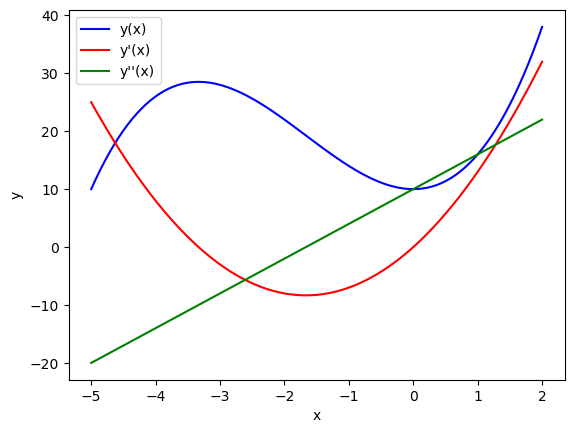

In [3]:
fig, ax = plt.subplots()
ax.plot(x, y, color="blue", label="y(x)")
ax.plot(x, y_1, color="red", label="y'(x)")
ax.plot(x, y_2, color="green", label="y''(x)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()

## The figure element
We can change the width and height of the canvas and set the number of pixels for each of them. We first need to set the figure's size in inches and then we set the resolution in dpi, that is the number of pixel per inch. 

In [4]:
x = np.linspace(-2, 2, 1000)
y1 = np.cos(40 * x)
y2 = np.exp(-x**2)

The axes coordinates are fractions of the canvas width and height

Text(0, 0.5, 'y')

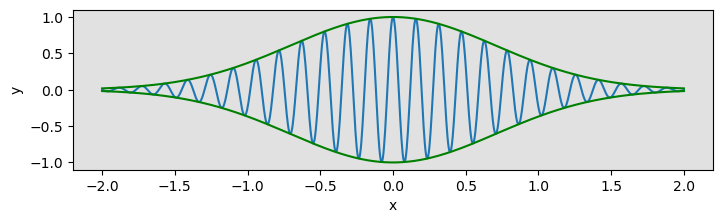

In [5]:
fig_width = 8.0
fig_height = 2.0
fig = plt.figure(figsize=(fig_width, fig_height), dpi=100)
left, bottom, width, height = 0.0, 0.0, 0.8, 0.8
ax = fig.add_axes((left, bottom, width, height), facecolor="#e1e1e1")
ax.plot(x, y1 * y2)
ax.plot(x, y2, 'g')
ax.plot(x, -y2, 'g')
ax.set_xlabel("x")
ax.set_ylabel("y")

## The axis element
The axes can be positioned everywhere in the figure's canvas. They have a cordinates system and are the elements used to create several types of plots. The subplots() function can be used to create a grid of e.g. 3 rows times two columns of axes 

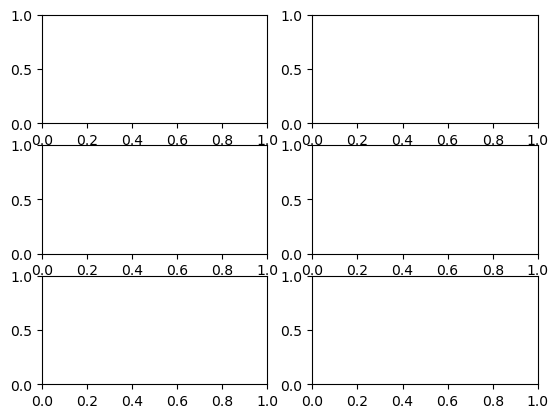

In [6]:
fig, axes = plt.subplots(nrows=3, ncols=2)

### Line plot
The axis object provides methods to create several types of plot: line plot, scatter plot, histograms, bar plot 

In [7]:
x = np.linspace(-3, 3, 25)
y1 = x**3+ 3 * x**2 + 10
y2 = -1.5 * x**3 + 10*x**2 - 15

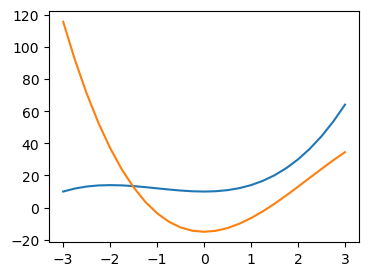

In [8]:
fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(x, y1)
ax.plot(x, y2)

We may want to remove the ticks label from a plot

In [9]:
fignum = 0
def hide_labels(fig, ax):
    global fignum
    ax.set_xticks([])
    ax.set_yticks([])
    ax.xaxis.set_ticks_position('none')
    ax.yaxis.set_ticks_position('none')
    ax.axis('tight')

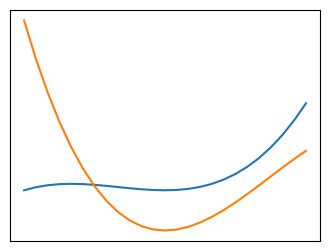

In [10]:
fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(x, y1)
ax.plot(x, y2)
hide_labels(fig, ax)

### Bar plot

<BarContainer object of 25 artists>

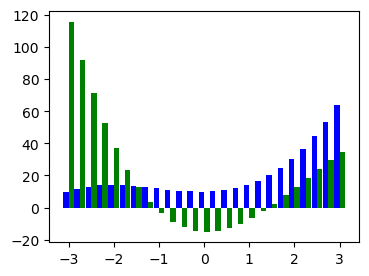

In [11]:
fig, ax = plt.subplots(figsize=(4, 3))
width = 6/50.0
ax.bar(x - width/2, y1, width=width, color="blue")
ax.bar(x + width/2, y2, width=width, color="green")

### Histograms

(array([7., 6., 4., 1., 0., 1., 0., 0., 1., 0., 0., 1., 0., 0., 1., 0., 0.,
        0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1.]),
 array([10. , 11.8, 13.6, 15.4, 17.2, 19. , 20.8, 22.6, 24.4, 26.2, 28. ,
        29.8, 31.6, 33.4, 35.2, 37. , 38.8, 40.6, 42.4, 44.2, 46. , 47.8,
        49.6, 51.4, 53.2, 55. , 56.8, 58.6, 60.4, 62.2, 64. ]),
 <BarContainer object of 30 artists>)

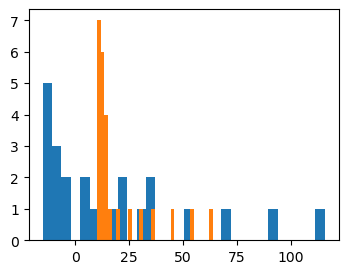

In [12]:
fig, ax = plt.subplots(figsize=(4, 3))
ax.hist(y2, bins=30)
ax.hist(y1, bins=30)

### Error bars

<ErrorbarContainer object of 3 artists>

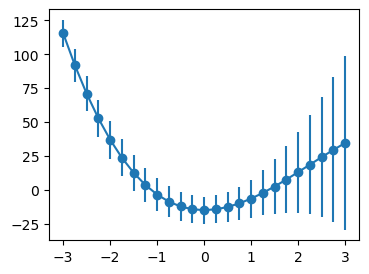

In [13]:
fig, ax = plt.subplots(figsize=(4, 3))
ax.errorbar(x, y2, yerr=y1, fmt='o-')

### Scatter plot

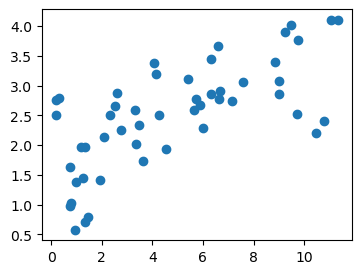

In [14]:
fig, ax = plt.subplots(figsize=(4, 3))
t = np.linspace(0, 5, 50)
x = -1 + t + 0.25 * t**2 + 2 * np.random.rand(len(t))
y = np.sqrt(t) + 2 * np.random.rand(len(t))
ax.scatter(x,y)

### 2D vector field

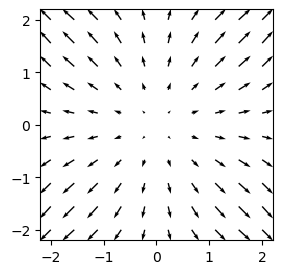

In [15]:
fig, ax = plt.subplots(figsize=(3, 3))
colors = ['yellowgreen', 'gold', 'lightskyblue', 'lightcoral']
x = y = np.linspace(-2, 2, 10)
X, Y = np.meshgrid(x, y)
U = np.sin(X)
V = np.sin(Y)
ax.quiver(X, Y, U, V)

## Line properties
A line is built from points. Both points and lines have properties that change the way they are visualized. A line's properties are width and style. A point's properties are type, size and color. We create four plots to show these properties.

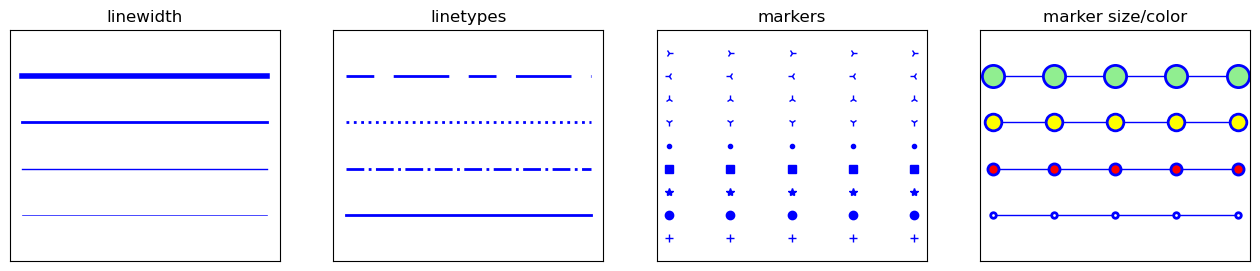

In [16]:
x = np.linspace(-5, 5, 5)
y = np.ones_like(x)

def axes_settings(fig, ax, title, ymax):
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_ylim(0, ymax+1)
    ax.set_title(title)

fig, axes = plt.subplots(1, 4, figsize=(16,3))
# Line width
linewidths = [0.5, 1.0, 2.0, 4.0]
for n, linewidth in enumerate(linewidths):
    axes[0].plot(x, y + n, color="blue", linewidth=linewidth)
axes_settings(fig, axes[0], "linewidth", len(linewidths))

# Line style
linestyles = ['-', '-.', ':']
for n, linestyle in enumerate(linestyles):
    axes[1].plot(x, y + n, color="blue", lw=2, linestyle=linestyle)

# custom dash style
line, = axes[1].plot(x, y + 3, color="blue", lw=2)
length1, gap1, length2, gap2 = 10, 7, 20, 7
line.set_dashes([length1, gap1, length2, gap2])
axes_settings(fig, axes[1], "linetypes", len(linestyles) + 1)

# marker types
markers = ['+', 'o', '*', 's', '.', '1', '2', '3', '4']
for n, marker in enumerate(markers):
    # lw = shorthand for linewidth, ls = shorthand for linestyle
    axes[2].plot(x, y + n, color="blue", lw=2, ls='None', marker=marker)
axes_settings(fig, axes[2], "markers", len(markers))
    
    
# marker size and color
markersizecolors = [(4, "white"), (8, "red"), (12, "yellow"), (16, "lightgreen")]
for n, (markersize, markerfacecolor) in enumerate (markersizecolors):
    axes[3].plot(x, y + n, color="blue", lw=1, ls='-',
                 marker='o', markersize=markersize,
                 markerfacecolor=markerfacecolor, markeredgewidth=2)
    
axes_settings(fig, axes[3], "marker size/color", len (markersizecolors))

One more example to show how to use the line's properties to underline one element of a plot. We build the Taylor expansion of the sin(x) function, form order 2 to order 12 and we plot all of them in the same canvas using different line types and widths. We start by defining a function that creates the Taylor expansions in symbols

In [17]:
sym_x = sympy.Symbol("x")
def sin_symbolic_expansion(sim_x, n):
    '''
    Symbolic Taylor expansion of order n of the sin(x) function
    '''
    return sympy.sin(sym_x).series(sym_x, 0, n = n + 1)

In [18]:
sin_symbolic_expansion(sym_x, 7)

x - x**3/6 + x**5/120 - x**7/5040 + O(x**8)

We define a function that calculates the numerical values of a Taylor series using the [SymPy's lambdify()](https://docs.sympy.org/latest/modules/utilities/lambdify.html) function

In [19]:
x = np.linspace(-2 * np.pi, 2 * np.pi, 100)
def sin_numerical_expansion(sym_x, x, n):
    """
    Evaluate the nth order Talyor series expansion
    of sin(x) for the numerical values in the array x.
    """
    return sympy.lambdify(sym_x, sin_symbolic_expansion(sym_x, n).removeO(), 'numpy')(x)

Finally we plot the sin(x) function and its Taylor expansions from order 2 to order 12

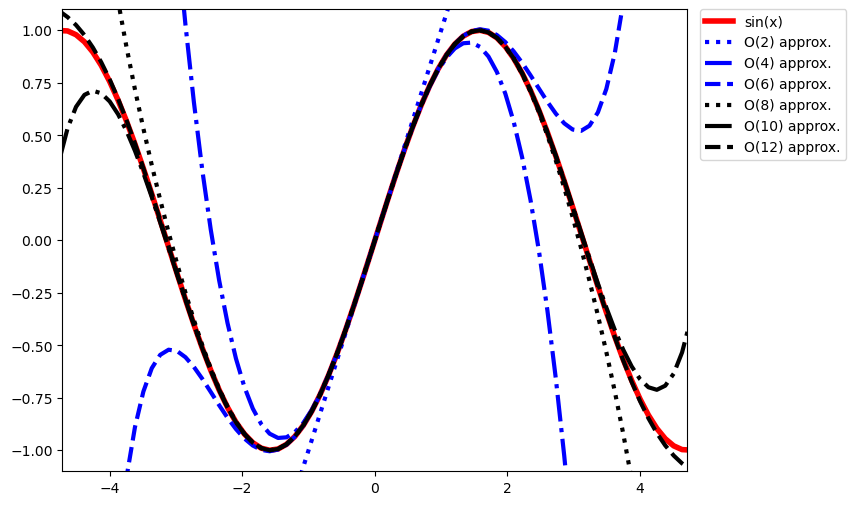

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x, np.sin(x), linewidth=4, color="red", label='sin(x)')
colors = ["blue", "black"]
linestyles = [':', '-.', '--']

for idx, n in enumerate(range(1, 12, 2)):
    ax.plot(x, sin_numerical_expansion(sym_x, x, n), color=colors[idx // 3],
            linestyle=linestyles[idx % 3], linewidth=3,
            label="O(%d) approx." % (n+1))
    
ax.set_ylim(-1.1, 1.1)
ax.set_xlim(-1.5*np.pi, 1.5*np.pi)
ax.legend(bbox_to_anchor=(1.02, 1), loc=2, borderaxespad=0.0)
fig.subplots_adjust(right=.75);